In [2]:
from pathlib import Path
from collections import defaultdict

root = Path("../data/raw/mrl")   # ../ porque el notebook está dentro de notebooks/
sujetos = defaultdict(set)
incoherentes = 0

for split in ["train", "val", "test"]:
    for cls in ["awake", "sleepy"]:
        for p in (root / split / cls).iterdir():
            campos = p.name.split("_")
            sujetos[split].add(campos[0])
            # campo 4 = estado del ojo (1 = abierto, 0 = cerrado)
            esperado = "1" if cls == "awake" else "0"
            if campos[4] != esperado:
                incoherentes += 1

for split, s in sujetos.items():
    print(f"{split}: {len(s)} sujetos distintos")

todos = set().union(*sujetos.values())
print("Sujetos totales:", len(todos))
print("Sujetos en train Y test:", len(sujetos["train"] & sujetos["test"]))
print("Archivos cuya carpeta no coincide con su estado de ojo:", incoherentes)

train: 37 sujetos distintos
val: 37 sujetos distintos
test: 37 sujetos distintos
Sujetos totales: 37
Sujetos en train Y test: 37
Archivos cuya carpeta no coincide con su estado de ojo: 0


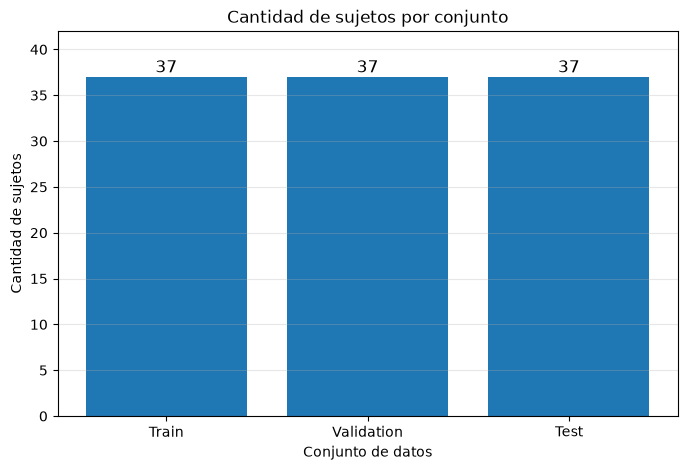

In [12]:
import matplotlib.pyplot as plt

# Cantidad de sujetos por cada conjunto
splits = ["Train", "Validation", "Test"]
cantidad_sujetos = [
    len(sujetos["train"]),
    len(sujetos["val"]),
    len(sujetos["test"])
]

# Crear gráfico
plt.figure(figsize=(8, 5))

barras = plt.bar(splits, cantidad_sujetos)

# Mostrar valores encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.5,
        str(int(altura)),
        ha="center",
        fontsize=12
    )

plt.title("Cantidad de sujetos por conjunto")
plt.xlabel("Conjunto de datos")
plt.ylabel("Cantidad de sujetos")
plt.ylim(0, max(cantidad_sujetos) + 5)
plt.grid(axis="y", alpha=0.3)

plt.show()

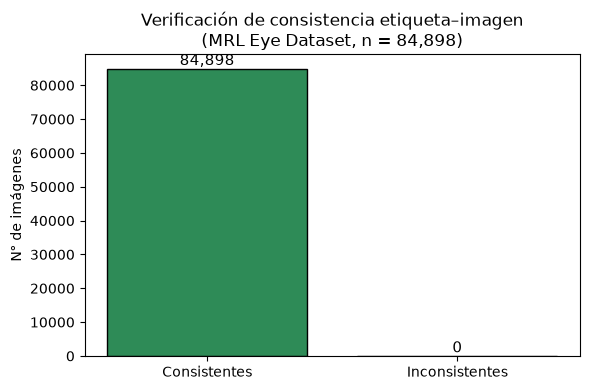

In [11]:
import matplotlib.pyplot as plt

total_imagenes = 84898
consistentes = total_imagenes - incoherentes

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Consistentes", "Inconsistentes"], [consistentes, incoherentes],
                 color=["seagreen", "indianred"], edgecolor="black")
ax.set_title("Verificación de consistencia etiqueta–imagen\n(MRL Eye Dataset, n = 84,898)")
ax.set_ylabel("N° de imágenes")

for barra, valor in zip(barras, [consistentes, incoherentes]):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f"{valor:,}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("../results/fig_consistencia_mrl.png", dpi=150, bbox_inches="tight")
plt.show()

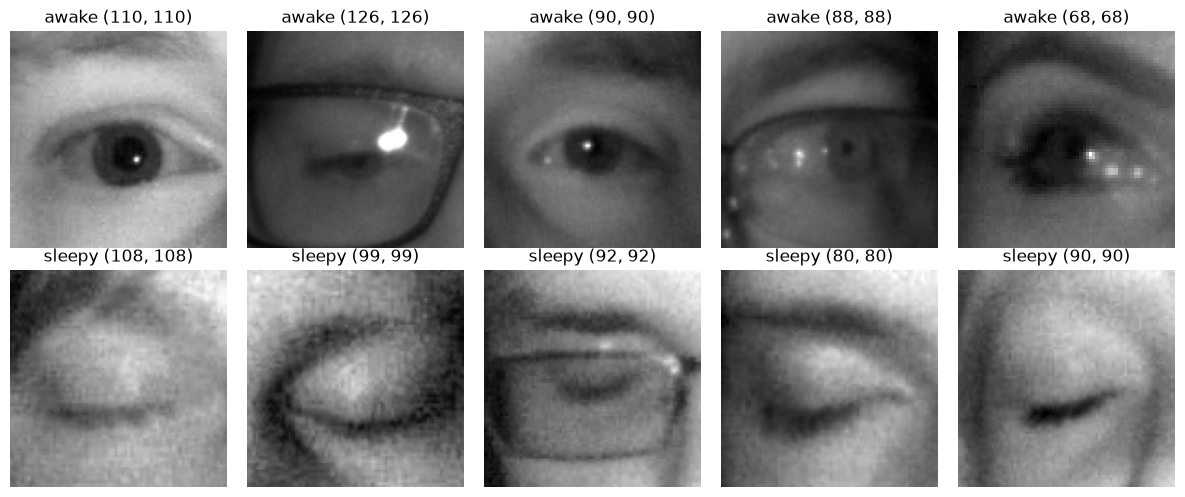

In [3]:
import random
from PIL import Image
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for fila, cls in enumerate(["awake", "sleepy"]):
    archivos = random.sample(list((root / "train" / cls).iterdir()), 5)
    for col, p in enumerate(archivos):
        img = Image.open(p)
        axes[fila, col].imshow(img, cmap="gray")
        axes[fila, col].set_title(f"{cls} {img.size}")
        axes[fila, col].axis("off")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from pathlib import Path

filas = []
for split in ["train", "val", "test"]:
    for cls in ["awake", "sleepy"]:
        for p in (root / split / cls).iterdir():
            c = p.stem.split("_")
            filas.append({
                "ruta": str(p.relative_to(root)),
                "archivo": p.name,
                "sujeto": c[0],
                "genero": c[2],
                "lentes": c[3],
                "ojo": int(c[4]),      # 1 = abierto, 0 = cerrado
                "reflejos": c[5],
                "luz": c[6],
                "sensor": c[7],
                "split_original": split,
            })

df = pd.DataFrame(filas)
print("Filas:", len(df), "| Nombres de archivo únicos:", df["archivo"].nunique())
df.head()

Filas: 84898 | Nombres de archivo únicos: 84898


,ruta,archivo,sujeto,genero,lentes,ojo,reflejos,luz,sensor,split_original
0,train\awake\s0001_01842_0_0_1_0_0_01.png,s0001_01842_0_0_1_0_0_01.png,s0001,0,0,1,0,0,01,train
1,train\awake\s0001_01843_0_0_1_0_0_01.png,s0001_01843_0_0_1_0_0_01.png,s0001,0,0,1,0,0,01,train
2,train\awake\s0001_01845_0_0_1_0_0_01.png,s0001_01845_0_0_1_0_0_01.png,s0001,0,0,1,0,0,01,train
3,train\awake\s0001_01848_0_0_1_0_0_01.png,s0001_01848_0_0_1_0_0_01.png,s0001,0,0,1,0,0,01,train
4,train\awake\s0001_01852_0_0_1_0_0_01.png,s0001_01852_0_0_1_0_0_01.png,s0001,0,0,1,0,0,01,train


In [4]:
resumen = df.groupby("sujeto").agg(
    n_imagenes=("ojo", "size"),
    prop_abiertos=("ojo", "mean"),
    lentes=("lentes", lambda s: s.mode()[0]),
).round(2)
print(resumen.describe())

sujetos = resumen.index.to_series().sample(frac=1, random_state=42).tolist()
train_s, val_s, test_s = sujetos[:25], sujetos[25:31], sujetos[31:]

mapa = {s: "train" for s in train_s} | {s: "val" for s in val_s} | {s: "test" for s in test_s}
df["split"] = df["sujeto"].map(mapa)

print()
print(pd.crosstab(df["split"], df["ojo"], margins=True))
print()
print("Proporción con lentes por partición:")
print(df.groupby("split")["lentes"].apply(lambda s: (s == "1").mean()).round(2))

         n_imagenes  prop_abiertos
count     37.000000      37.000000
mean    2294.540541       0.495405
std     2659.071931       0.359518
min      382.000000       0.000000
25%      704.000000       0.160000
50%     1114.000000       0.530000
75%     1889.000000       0.860000
max    10257.000000       0.980000

ojo        0      1    All
split                     
test    4890   6151  11041
train  33899  33370  67269
val     3157   3431   6588
All    41946  42952  84898

Proporción con lentes por partición:
split
test     0.13
train    0.32
val      0.16
Name: lentes, dtype: float64


In [5]:
resumen = df.groupby("sujeto").agg(
    n_imagenes=("ojo", "size"),
    prop_abiertos=("ojo", "mean"),
    lentes=("lentes", lambda s: s.mode()[0]),
).round(2)
print(resumen.describe())

sujetos = resumen.index.to_series().sample(frac=1, random_state=42).tolist()
train_s, val_s, test_s = sujetos[:25], sujetos[25:31], sujetos[31:]

mapa = {s: "train" for s in train_s} | {s: "val" for s in val_s} | {s: "test" for s in test_s}
df["split"] = df["sujeto"].map(mapa)

print()
print(pd.crosstab(df["split"], df["ojo"], margins=True))
print()
print("Proporción con lentes por partición:")
print(df.groupby("split")["lentes"].apply(lambda s: (s == "1").mean()).round(2))

         n_imagenes  prop_abiertos
count     37.000000      37.000000
mean    2294.540541       0.495405
std     2659.071931       0.359518
min      382.000000       0.000000
25%      704.000000       0.160000
50%     1114.000000       0.530000
75%     1889.000000       0.860000
max    10257.000000       0.980000

ojo        0      1    All
split                     
test    4890   6151  11041
train  33899  33370  67269
val     3157   3431   6588
All    41946  42952  84898

Proporción con lentes por partición:
split
test     0.13
train    0.32
val      0.16
Name: lentes, dtype: float64


In [6]:
print("Sujetos por partición:", df.groupby("split")["sujeto"].nunique().to_dict())
print("Sujetos compartidos train/test:", len(set(train_s) & set(test_s)))
print("Sujetos compartidos train/val:", len(set(train_s) & set(val_s)))
print("Sujetos compartidos val/test:", len(set(val_s) & set(test_s)))

Path("../results").mkdir(exist_ok=True)
df.to_csv("../results/mrl_metadata.csv", index=False)
print("Guardado en results/mrl_metadata.csv")

Sujetos por partición: {'test': 6, 'train': 25, 'val': 6}
Sujetos compartidos train/test: 0
Sujetos compartidos train/val: 0
Sujetos compartidos val/test: 0
Guardado en results/mrl_metadata.csv


In [7]:
por_sujeto = df.groupby("sujeto")["ojo"].agg(["nunique", "count"])
por_sujeto.columns = ["clases_distintas", "n_imagenes"]

print(por_sujeto.head(10))
print()
print("Sujetos con AMBAS clases (abierto y cerrado):", (por_sujeto["clases_distintas"] == 2).sum())
print("Sujetos con UNA sola clase:", (por_sujeto["clases_distintas"] == 1).sum())
print("Total de sujetos:", len(por_sujeto))

        clases_distintas  n_imagenes
sujeto                              
s0001                  2        3242
s0002                  2        1114
s0003                  2         679
s0004                  1        1069
s0005                  2         736
s0006                  2        1012
s0007                  2         624
s0008                  1         832
s0009                  2         387
s0010                  2         399

Sujetos con AMBAS clases (abierto y cerrado): 35
Sujetos con UNA sola clase: 2
Total de sujetos: 37


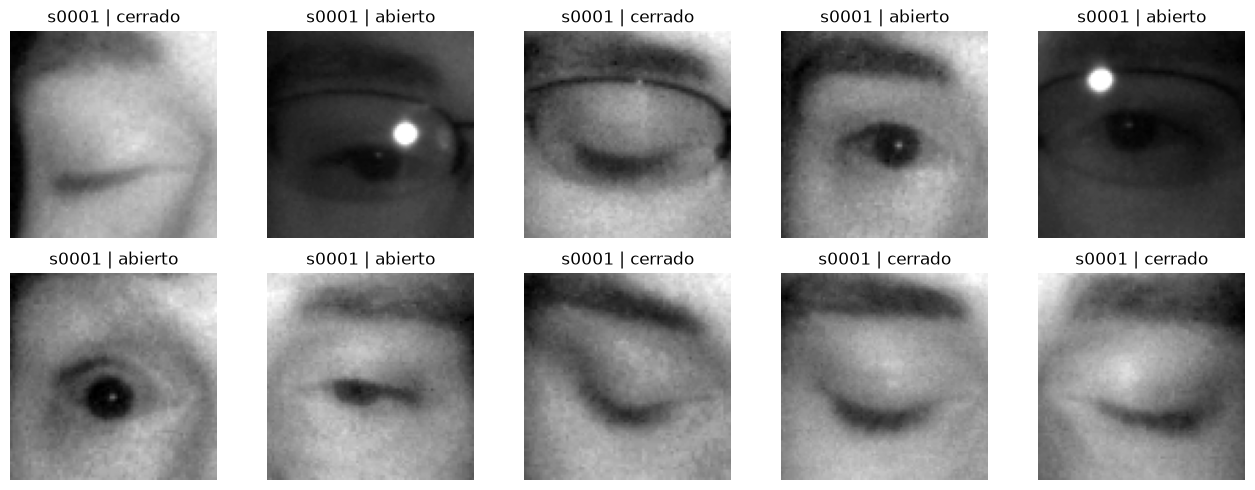

In [8]:
from PIL import Image
from matplotlib import pyplot as plt

sujeto_ejemplo = "s0001"
fotos_sujeto = df[df["sujeto"] == sujeto_ejemplo].sample(10, random_state=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, (_, fila) in zip(axes.flat, fotos_sujeto.iterrows()):
    img = Image.open(root / fila["ruta"])
    etiqueta = "abierto" if fila["ojo"] == 1 else "cerrado"
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{sujeto_ejemplo} | {etiqueta}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Sujeto: s0003
Etiqueta: cerrado
Tamaño de imagen: (86, 86)


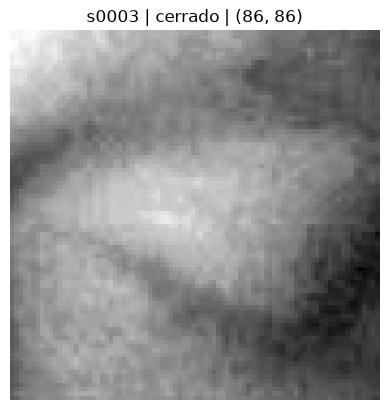

In [9]:
import random

fila = df.sample(1, random_state=3).iloc[0]
img = Image.open(root / fila["ruta"])

print("Sujeto:", fila["sujeto"])
print("Etiqueta:", "abierto" if fila["ojo"] == 1 else "cerrado")
print("Tamaño de imagen:", img.size)

plt.imshow(img, cmap="gray")
plt.title(f"{fila['sujeto']} | {'abierto' if fila['ojo']==1 else 'cerrado'} | {img.size}")
plt.axis("off")
plt.show()

In [5]:
# En 01_exploracion_mrl.ipynb o 02_entrenamiento_cnn.ipynb, con df ya cargado
total = len(df)

resumen_atributos = []
for col, nombre in [("ojo", "Estado ocular"), ("lentes", "Lentes"),
                     ("luz", "Iluminación"), ("reflejos", "Reflejos")]:
    conteo = df[col].value_counts()
    for valor, n in conteo.items():
        resumen_atributos.append({
            "Atributo": nombre, "Categoría": valor,
            "Imágenes": n, "Porcentaje": round(100*n/total, 1)
        })

tabla_atributos = pd.DataFrame(resumen_atributos)
print(tabla_atributos.to_string(index=False))
tabla_atributos.to_csv("../results/mrl_distribucion_atributos.csv", index=False)

     Atributo Categoría  Imágenes  Porcentaje
Estado ocular         1     42952        50.6
Estado ocular         0     41946        49.4
       Lentes         0     60897        71.7
       Lentes         1     24001        28.3
  Iluminación         0     53630        63.2
  Iluminación         1     31268        36.8
     Reflejos         0     66227        78.0
     Reflejos         2     12709        15.0
     Reflejos         1      5962         7.0


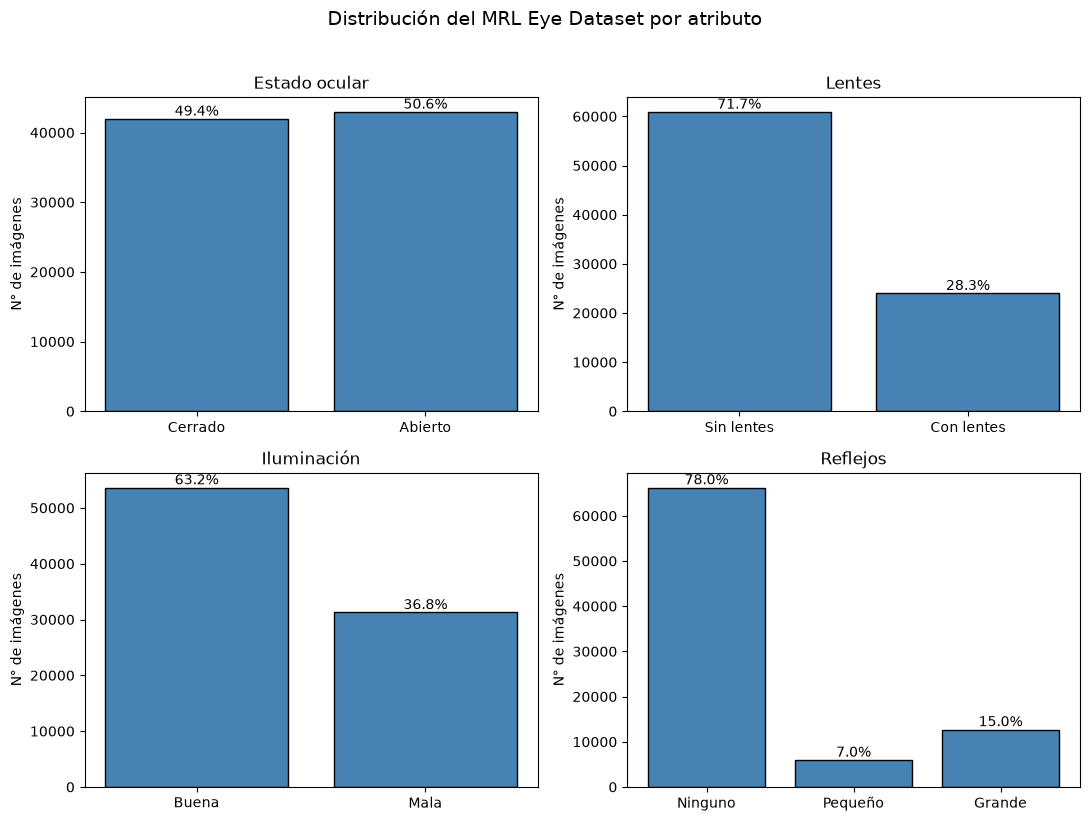

In [10]:
import matplotlib.pyplot as plt

etiquetas = {
    "Estado ocular": {1: "Abierto", 0: "Cerrado"},
    "Lentes": {1: "Con lentes", 0: "Sin lentes"},
    "Iluminación": {1: "Mala", 0: "Buena"},
    "Reflejos": {0: "Ninguno", 1: "Pequeño", 2: "Grande"},
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, atributo in enumerate(["Estado ocular", "Lentes", "Iluminación", "Reflejos"]):
    datos = tabla_atributos[tabla_atributos["Atributo"] == atributo].copy()
    datos["Categoría"] = datos["Categoría"].astype(int)          # ← la línea que faltaba
    datos["Categoría_nombre"] = datos["Categoría"].map(etiquetas[atributo])
    datos = datos.sort_values("Categoría")                        # opcional: orden consistente

    barras = axes[i].bar(datos["Categoría_nombre"], datos["Imágenes"], color="steelblue", edgecolor="black")
    axes[i].set_title(atributo, fontsize=12)
    axes[i].set_ylabel("N° de imágenes")

    for barra, pct in zip(barras, datos["Porcentaje"]):
        axes[i].text(barra.get_x() + barra.get_width()/2, barra.get_height(),
                     f"{pct}%", ha="center", va="bottom", fontsize=10)

plt.suptitle("Distribución del MRL Eye Dataset por atributo", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/fig_distribucion_mrl.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
from PIL import Image
tamanos = [Image.open(root / r).size[0] for r in df.sample(200, random_state=1)["ruta"]]
print("Tamaño de lado — mínimo:", min(tamanos), "máximo:", max(tamanos),
      "mediana:", int(pd.Series(tamanos).median()))

print(df.groupby("sujeto").size().describe())

Tamaño de lado — mínimo: 60 máximo: 176 mediana: 90
count       37.000000
mean      2294.540541
std       2659.071931
min        382.000000
25%        704.000000
50%       1114.000000
75%       1889.000000
max      10257.000000
dtype: float64


C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_17560\898334556.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(imgs_por_sujeto, vert=True)


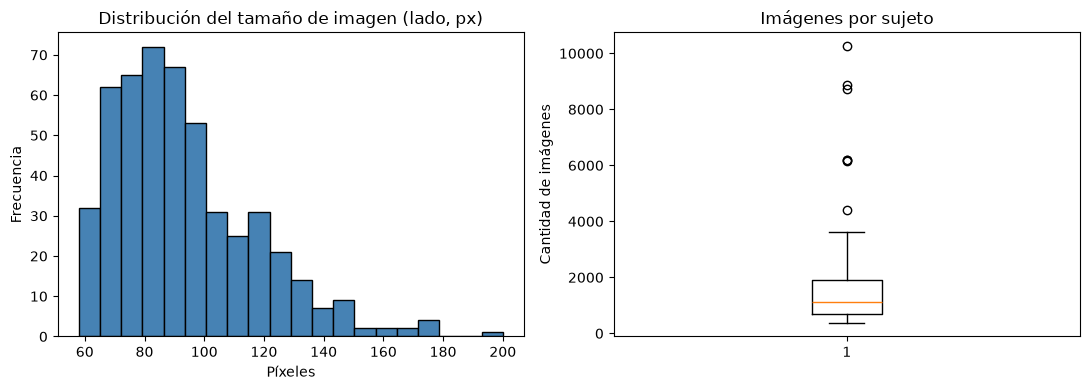

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tamanos_muestra = [Image.open(root / r).size[0] for r in df.sample(500, random_state=1)["ruta"]]
axes[0].hist(tamanos_muestra, bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Distribución del tamaño de imagen (lado, px)")
axes[0].set_xlabel("Píxeles"); axes[0].set_ylabel("Frecuencia")

imgs_por_sujeto = df.groupby("sujeto").size()
axes[1].boxplot(imgs_por_sujeto, vert=True)
axes[1].set_title("Imágenes por sujeto")
axes[1].set_ylabel("Cantidad de imágenes")

plt.tight_layout()
plt.savefig("../results/fig_tamano_y_sujeto_mrl.png", dpi=150, bbox_inches="tight")
plt.show()